In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/datasets_11657_16098_train.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
x = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']
x

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500
...,...,...,...,...
886,2,male,27.0,13.0000
887,1,female,19.0,30.0000
888,3,female,NaN,23.4500
889,1,male,26.0,30.0000


In [4]:
x.loc[:, 'Sex'] = x['Sex'].map({'male': 0, 'female': 1}).astype('Int64')
display(x.head())

,Pclass,Sex,Age,Fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,1,26.0,7.9250
3,1,1,35.0,53.1000
4,3,0,35.0,8.0500


In [5]:
y.isnull().sum()

np.int64(0)

In [6]:
x.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
Fare,0


In [7]:
median_age = x['Age'].median()
x.loc[:, 'Age'] = x['Age'].fillna(median_age)
display(x.head())
x.isnull().sum()

,Pclass,Sex,Age,Fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,1,26.0,7.9250
3,1,1,35.0,53.1000
4,3,0,35.0,8.0500


,0
Pclass,0
Sex,0
Age,0
Fare,0


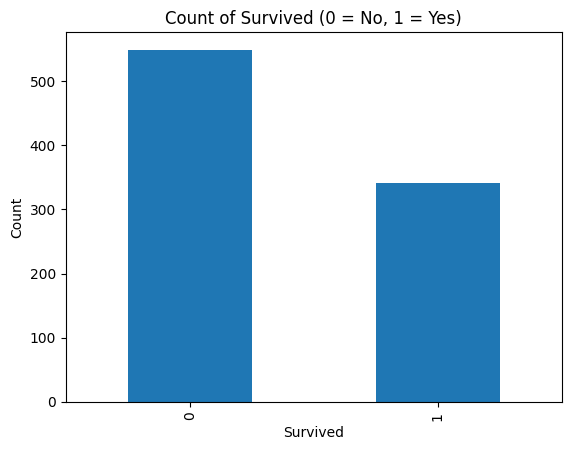

In [8]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title('Count of Survived (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [10]:
from sklearn.tree import DecisionTreeClassifier

model_1 = DecisionTreeClassifier(max_depth=3)
model_1.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3)

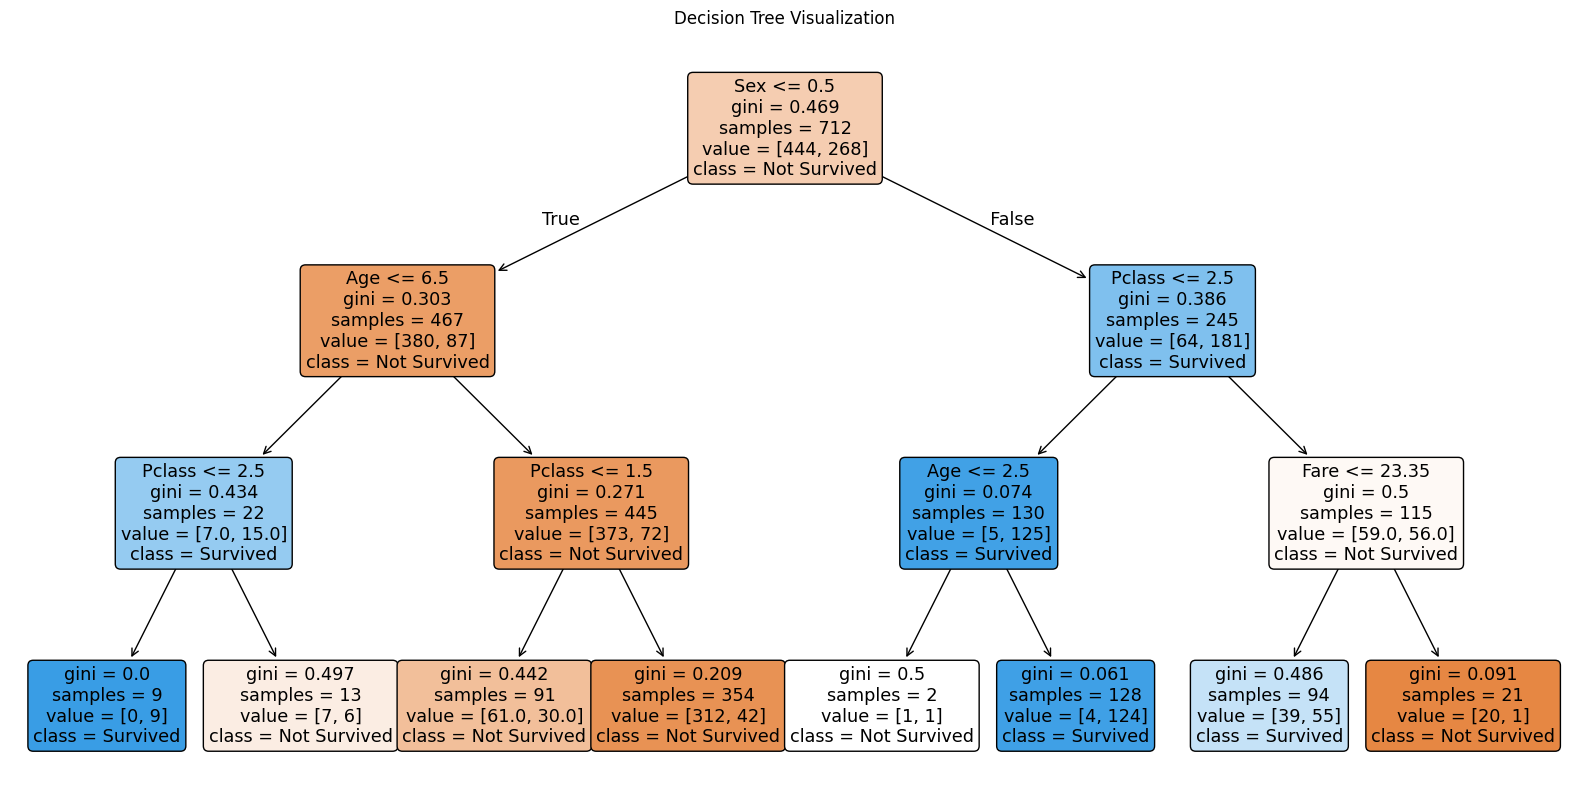

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model_1, filled=True, feature_names=x.columns, class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

In [12]:
from sklearn.metrics import classification_report

y_pred_train = model_1.predict(X_train)
print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_train))

y_pred = model_1.predict(X_test)
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred))

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       444
           1       0.81      0.70      0.75       268

    accuracy                           0.83       712
   macro avg       0.82      0.80      0.81       712
weighted avg       0.83      0.83      0.82       712


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for max_depth
param_grid = {'max_depth': range(2, 21)}

# Initialize Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)

# Store the best model
best_model = grid_search.best_estimator_

Best parameters found:  {'max_depth': 3}
Best accuracy score:  0.8117797695262483


In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Apply SMOTE to balance the training dataset
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape, y_train.shape}")
print(f"Resampled training set shape: {X_train_res.shape, y_train_res.shape}")
print(f"Resampled class distribution: {y_train_res.value_counts()}")

# Train a Decision Tree model on the SMOTE-resampled data
# Using the best_model from GridSearchCV (max_depth=3)
model_smote = DecisionTreeClassifier(max_depth=3, random_state=42)
model_smote.fit(X_train_res, y_train_res)

# Evaluate the model on the resampled training data
y_pred_train_smote = model_smote.predict(X_train_res)
print("\nClassification Report for SMOTE-resampled Training Set:")
print(classification_report(y_train_res, y_pred_train_smote))

# Evaluate the model on the original test data
y_pred_test_smote = model_smote.predict(X_test)
print("\nClassification Report for Test Set (after SMOTE training):")
print(classification_report(y_test, y_pred_test_smote))

Original training set shape: ((712, 4), (712,))
Resampled training set shape: ((888, 4), (888,))
Resampled class distribution: Survived
0    444
1    444
Name: count, dtype: int64

Classification Report for SMOTE-resampled Training Set:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       444
           1       0.89      0.76      0.82       444

    accuracy                           0.83       888
   macro avg       0.84      0.83      0.83       888
weighted avg       0.84      0.83      0.83       888


Classification Report for Test Set (after SMOTE training):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## Ensemble Models Comparison

Let's compare the performance of Bagging with Logistic Regression, Bagging with Decision Trees, and Random Forest.

In [18]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Bagging with Logistic Regression
print("\n--- Bagging with Logistic Regression ---")
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Use liblinear for small datasets
bagging_lr_model = BaggingClassifier(estimator=log_reg, n_estimators=50, random_state=42, n_jobs=-1)
bagging_lr_model.fit(X_train, y_train)

# Training set report
y_pred_bagging_lr_train = bagging_lr_model.predict(X_train)
print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_bagging_lr_train))

# Test set report
y_pred_bagging_lr = bagging_lr_model.predict(X_test)
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred_bagging_lr))


--- Bagging with Logistic Regression ---
Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       444
           1       0.73      0.69      0.71       268

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.77       712
weighted avg       0.79      0.79      0.79       712


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [19]:
# 2. Bagging with Decision Trees (similar to Random Forest without bootstrap aggregation if max_features is 1)
print("\n--- Bagging with Decision Trees ---")
dt_base = DecisionTreeClassifier(max_depth=3, random_state=42) # Using max_depth=3 for consistency
bagging_dt_model = BaggingClassifier(estimator=dt_base, n_estimators=50, random_state=42, n_jobs=-1)
bagging_dt_model.fit(X_train, y_train)

# Training set report
y_pred_bagging_dt_train = bagging_dt_model.predict(X_train)
print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_bagging_dt_train))

# Test set report
y_pred_bagging_dt = bagging_dt_model.predict(X_test)
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred_bagging_dt))


--- Bagging with Decision Trees ---
Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       444
           1       0.81      0.72      0.76       268

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [21]:
# 3. Random Forest Classifier (Bagging + DT + Bootstrap Aggregation)
print("\n--- Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42, n_jobs=-1) # Using max_depth=3
rf_model.fit(X_train, y_train)

# Training set report
y_pred_rf_train = rf_model.predict(X_train)
print("Classification Report for Training Set:")
print(classification_report(y_train, y_pred_rf_train))

# Test set report
y_pred_rf = rf_model.predict(X_test)
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_pred_rf))


--- Random Forest Classifier ---
Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       444
           1       0.86      0.71      0.77       268

    accuracy                           0.84       712
   macro avg       0.85      0.82      0.83       712
weighted avg       0.85      0.84      0.84       712


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       105
           1       0.81      0.62      0.70        74

    accuracy                           0.78       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.78      0.78       179

